In [ ]:
# Partie 0 — imports et constantes
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.datasets import make_classification
from sklearn.ensemble import (
    AdaBoostClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
resultats = []  # tableau final (partie 4)


def evaluer(nom, modele, X_train, y_train, X_test, y_test, t_fit):
    """Calcule accuracy train/test et stocke une ligne pour le bilan."""
    acc_train = accuracy_score(y_train, modele.predict(X_train))
    acc_test = accuracy_score(y_test, modele.predict(X_test))
    resultats.append(
        {
            "Modèle": nom,
            "Accuracy (Train)": acc_train,
            "Accuracy (Test)": acc_test,
            "Temps d'entraînement (s)": t_fit,
        }
    )
    print(f"{nom:20s}  train={acc_train:.4f}  test={acc_test:.4f}  time={t_fit:.3f}s")

In [ ]:
# Partie 0 — jeu synthétique : 2500 samples, 20 features (12 informatives), 2 classes
X, y = make_classification(
    n_samples=2500,
    n_features=20,
    n_informative=12,
    n_redundant=4,
    n_classes=2,
    random_state=RANDOM_STATE,
)

# Split stratifié 80/20 pour garder le même équilibre de classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape, np.bincount(y))

(2000, 20) (500, 20) [1252 1248]


In [ ]:
# Partie 1.1 — baseline : un seul arbre CART, profondeur illimitée
# Si train ≈ 100 % et test nettement plus bas → surapprentissage
arbre = DecisionTreeClassifier(random_state=RANDOM_STATE)
t0 = time.perf_counter()
arbre.fit(X_train, y_train)
t_arbre = time.perf_counter() - t0
evaluer("Arbre Seul", arbre, X_train, y_train, X_test, y_test, t_arbre)

Arbre Seul            train=1.0000  test=0.8160  time=0.042s


In [ ]:
# Partie 1.2 — Bagging manuel (B = 50)
# 1) bootstrap : tirage avec remise
# 2) un arbre par échantillon
# 3) agrégation : vote majoritaire

B = 50
rng = np.random.RandomState(RANDOM_STATE)
n = X_train.shape[0]
arbres_bagging = []

t0 = time.perf_counter()
for b in range(B):
    idx = rng.choice(n, size=n, replace=True)  # échantillon bootstrap
    arbre_b = DecisionTreeClassifier(random_state=RANDOM_STATE + b)
    arbre_b.fit(X_train[idx], y_train[idx])
    arbres_bagging.append(arbre_b)
t_bag = time.perf_counter() - t0


def predire_bagging(X):
    preds = np.vstack([clf.predict(X) for clf in arbres_bagging])
    # vote majoritaire colonne par colonne
    return np.apply_along_axis(lambda col: np.bincount(col).argmax(), axis=0, arr=preds)


acc_train = accuracy_score(y_train, predire_bagging(X_train))
acc_test = accuracy_score(y_test, predire_bagging(X_test))
resultats.append(
    {
        "Modèle": "Bagging manuel",
        "Accuracy (Train)": acc_train,
        "Accuracy (Test)": acc_test,
        "Temps d'entraînement (s)": t_bag,
    }
)
print(f"{'Bagging manuel':20s}  train={acc_train:.4f}  test={acc_test:.4f}  time={t_bag:.3f}s")

Bagging manuel        train=1.0000  test=0.8980  time=1.971s


max_features=toutes    train=0.9995  test=0.8880
max_features=sqrt      train=0.9995  test=0.9160
max_features=log2      train=0.9995  test=0.9160
max_features=0.3       train=1.0000  test=0.9220
max_features=0.5       train=1.0000  test=0.9100
Random Forest         train=1.0000  test=0.9220  time=0.171s
meilleur max_features = 0.3


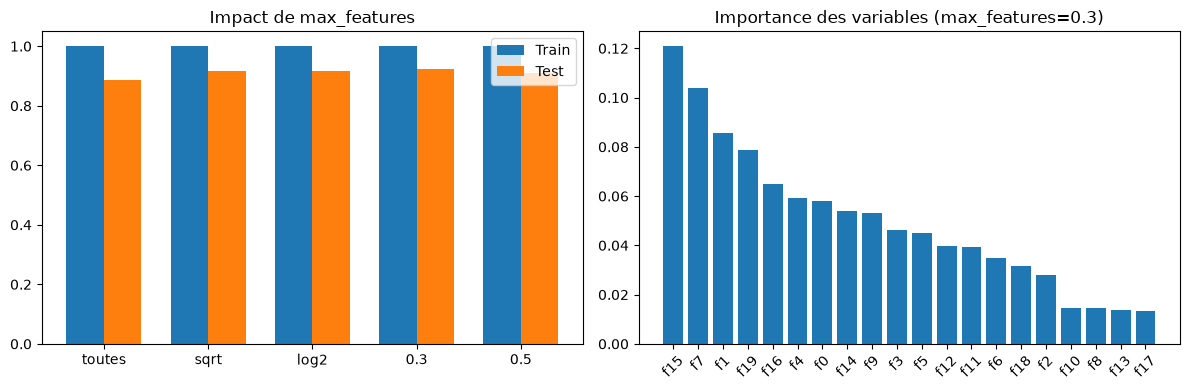

In [ ]:
# Partie 1.3 — Random Forest
# max_features limite les variables à chaque nœud → arbres plus diversifiés que le bagging
grille_mf = [None, "sqrt", "log2", 0.3, 0.5]
meilleur_rf, meilleur_test, meilleur_mf, t_rf = None, -1.0, None, 0.0
scores_mf = []

for mf in grille_mf:
    rf = RandomForestClassifier(
        n_estimators=50,
        max_features=mf,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    t0 = time.perf_counter()
    rf.fit(X_train, y_train)
    t = time.perf_counter() - t0
    acc_tr = accuracy_score(y_train, rf.predict(X_train))
    acc_te = accuracy_score(y_test, rf.predict(X_test))
    label = "toutes" if mf is None else str(mf)
    scores_mf.append((label, acc_tr, acc_te))
    print(f"max_features={label:8s}  train={acc_tr:.4f}  test={acc_te:.4f}")
    if acc_te > meilleur_test:
        meilleur_rf, meilleur_test, meilleur_mf, t_rf = rf, acc_te, label, t

evaluer("Random Forest", meilleur_rf, X_train, y_train, X_test, y_test, t_rf)
print("meilleur max_features =", meilleur_mf)

# Importance des variables (Mean Decrease Impurity)
importances = meilleur_rf.feature_importances_
ordre = np.argsort(importances)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = [s[0] for s in scores_mf]
x = np.arange(len(labels))
axes[0].bar(x - 0.18, [s[1] for s in scores_mf], 0.36, label="Train")
axes[0].bar(x + 0.18, [s[2] for s in scores_mf], 0.36, label="Test")
axes[0].set_xticks(x, labels)
axes[0].set_title("Impact de max_features")
axes[0].legend()

axes[1].bar(range(len(importances)), importances[ordre])
axes[1].set_xticks(range(len(importances)), [f"f{i}" for i in ordre], rotation=45)
axes[1].set_title(f"Importance des variables (max_features={meilleur_mf})")
plt.tight_layout()
plt.show()

learning_rate=0.1  train=0.8030  test=0.7540
learning_rate=0.5  train=0.8325  test=0.7680
learning_rate=1.0  train=0.8415  test=0.7960
learning_rate=1.5  train=0.8740  test=0.7820
AdaBoost              train=0.8415  test=0.7960  time=1.447s
meilleur learning_rate = 1.0


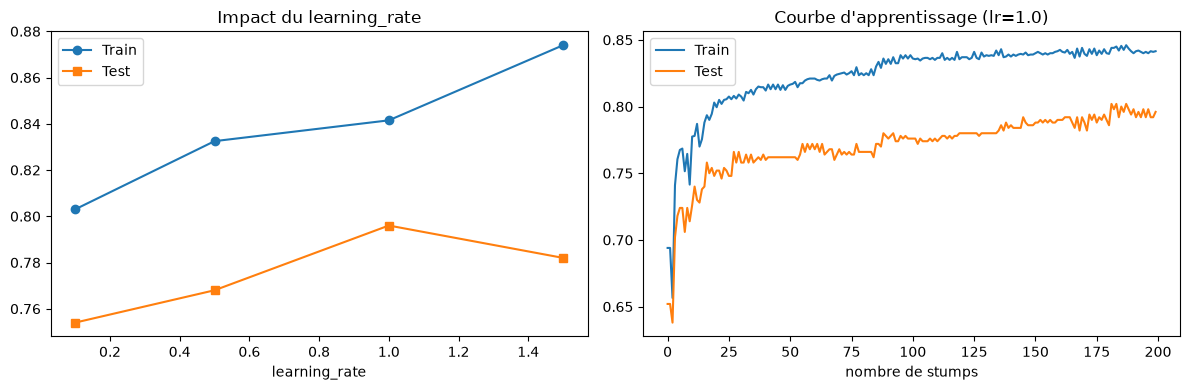

In [ ]:
# Partie 2.1 — AdaBoost : stumps (profondeur 1), chaque modèle corrige les erreurs du précédent
# learning_rate contrôle l'amplitude de la mise à jour des poids
stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
learning_rates = [0.1, 0.5, 1.0, 1.5]
meilleur_ada, meilleur_test, meilleur_lr, t_ada = None, -1.0, None, 0.0
courbes = []

for lr in learning_rates:
    ada = AdaBoostClassifier(
        estimator=stump,
        n_estimators=200,
        learning_rate=lr,
        random_state=RANDOM_STATE,
    )
    t0 = time.perf_counter()
    ada.fit(X_train, y_train)
    t = time.perf_counter() - t0
    acc_tr = accuracy_score(y_train, ada.predict(X_train))
    acc_te = accuracy_score(y_test, ada.predict(X_test))
    courbes.append((lr, acc_tr, acc_te))
    print(f"learning_rate={lr:.1f}  train={acc_tr:.4f}  test={acc_te:.4f}")
    if acc_te > meilleur_test:
        meilleur_ada, meilleur_test, meilleur_lr, t_ada = ada, acc_te, lr, t

evaluer("AdaBoost", meilleur_ada, X_train, y_train, X_test, y_test, t_ada)
print("meilleur learning_rate =", meilleur_lr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot([c[0] for c in courbes], [c[1] for c in courbes], "o-", label="Train")
axes[0].plot([c[0] for c in courbes], [c[2] for c in courbes], "s-", label="Test")
axes[0].set_xlabel("learning_rate")
axes[0].set_title("Impact du learning_rate")
axes[0].legend()

# Accuracy après chaque stump ajouté (meilleur lr)
axes[1].plot(list(meilleur_ada.staged_score(X_train, y_train)), label="Train")
axes[1].plot(list(meilleur_ada.staged_score(X_test, y_test)), label="Test")
axes[1].set_xlabel("nombre de stumps")
axes[1].set_title(f"Courbe d'apprentissage (lr={meilleur_lr})")
axes[1].legend()
plt.tight_layout()
plt.show()

meilleure itération test : 200 / 200
XGBoost               train=0.9895  test=0.9320  time=0.321s


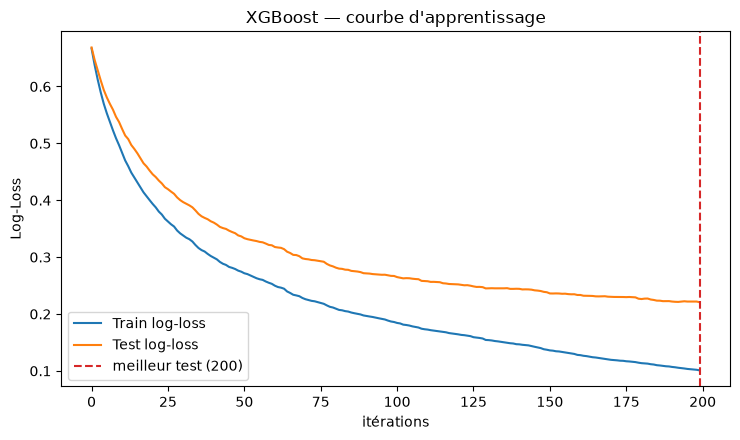

In [ ]:
# Partie 2.2 — XGBoost : gradient boosting, eval_set pour tracer le log-loss
# Si le log-loss test remonte alors que le train baisse → début de surapprentissage
n_rounds = 200
xgb = XGBClassifier(
    n_estimators=n_rounds,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

t0 = time.perf_counter()
xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)
t_xgb = time.perf_counter() - t0

evals = xgb.evals_result()
ll_train = np.array(evals["validation_0"]["logloss"])
ll_test = np.array(evals["validation_1"]["logloss"])
best_iter = int(np.argmin(ll_test))  # itération au plus bas log-loss test
print(f"meilleure itération test : {best_iter + 1} / {n_rounds}")

evaluer("XGBoost", xgb, X_train, y_train, X_test, y_test, t_xgb)

plt.figure(figsize=(7.5, 4.5))
plt.plot(ll_train, label="Train log-loss")
plt.plot(ll_test, label="Test log-loss")
plt.axvline(best_iter, color="C3", ls="--", label=f"meilleur test ({best_iter + 1})")
plt.xlabel("itérations")
plt.ylabel("Log-Loss")
plt.title("XGBoost — courbe d'apprentissage")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Partie 3 — modèles hétérogènes : LR, SVM, RF, XGBoost
# StandardScaler pour LR et SVM (sensibles à l'échelle des features)
lr = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)
svm = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "clf",
            CalibratedClassifierCV(  # proba pour le soft voting (sklearn >= 1.9)
                SVC(kernel="rbf", random_state=RANDOM_STATE),
                ensemble=False,
            ),
        ),
    ]
)
estimateurs = [
    ("logreg", lr),
    ("svm", svm),
    ("rf", RandomForestClassifier(n_estimators=50, max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1)),
    ("xgb", XGBClassifier(n_estimators=80, learning_rate=0.1, max_depth=3, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)),
]

# Hard voting : vote sur la classe prédite
hard = VotingClassifier(estimators=estimateurs, voting="hard", n_jobs=-1)
t0 = time.perf_counter()
hard.fit(X_train, y_train)
evaluer("Voting (hard)", hard, X_train, y_train, X_test, y_test, time.perf_counter() - t0)

# Soft voting : moyenne des probabilités
soft = VotingClassifier(estimators=estimateurs, voting="soft", n_jobs=-1)
t0 = time.perf_counter()
soft.fit(X_train, y_train)
evaluer("Voting (soft)", soft, X_train, y_train, X_test, y_test, time.perf_counter() - t0)

# Stacking : un méta-modèle (LR) apprend à combiner les prédictions (via CV)
stack = StackingClassifier(
    estimators=estimateurs,
    final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    cv=5,
    n_jobs=-1,
)
t0 = time.perf_counter()
stack.fit(X_train, y_train)
evaluer("Stacking", stack, X_train, y_train, X_test, y_test, time.perf_counter() - t0)

Voting (hard)         train=0.9560  test=0.9240  time=0.613s
Voting (soft)         train=0.9785  test=0.9380  time=0.687s
Stacking              train=0.9820  test=0.9600  time=2.232s


,Modèle,Accuracy (Train),Accuracy (Test),Temps d'entraînement (s)
0,Arbre Seul,1.0000,0.816,0.042057
1,Bagging manuel,1.0000,0.898,1.970771
2,Random Forest,1.0000,0.922,0.170824
3,AdaBoost,0.8415,0.796,1.446680
4,XGBoost,0.9895,0.932,0.320664
5,Voting (hard),0.9560,0.924,0.612780
6,Voting (soft),0.9785,0.938,0.687002
7,Stacking,0.9820,0.960,2.231698


Résultat enregistré dans : figures_et_resultat\resultats_modeles.csv
Figure enregistrée dans : figures_et_resultat\comparaison_modeles.png


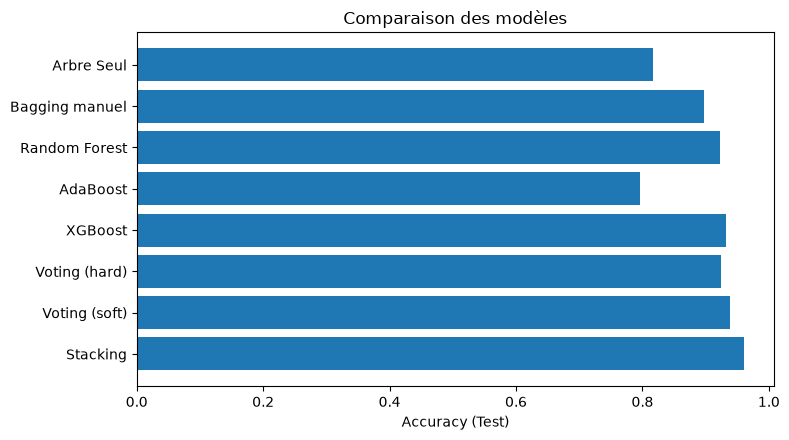

In [ ]:
# Partie 4 — tableau récapitulatif demandé dans le sujet
from pathlib import Path

output_dir = Path("figures_et_resultat")
output_dir.mkdir(exist_ok=True)

df = pd.DataFrame(resultats)
display(df)
df.to_csv(output_dir / "resultats_modeles.csv", index=False)
print(f"Résultat enregistré dans : {output_dir / 'resultats_modeles.csv'}")

plt.figure(figsize=(8, 4.5))
plt.barh(df["Modèle"][::-1], df["Accuracy (Test)"][::-1])
plt.xlabel("Accuracy (Test)")
plt.title("Comparaison des modèles")
plt.tight_layout()
plt.savefig(output_dir / "comparaison_modeles.png", dpi=300, bbox_inches="tight")
print(f"Figure enregistrée dans : {output_dir / 'comparaison_modeles.png'}")
plt.show()